In [106]:
url = 'https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv'

import pandas as pd
import numpy as np

data = pd.read_csv(url)
data


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [107]:
data = data.drop(columns=['Id'])

data['Has_Alley'] = data['Alley'].notna().astype(int)
data = data.drop(columns=['Alley'])

data['LotFrontage'] = data['LotFrontage'].fillna(0)
data['MasVnrArea'] = data['MasVnrArea'].fillna(0)

# MasVnrType: Masonry veneer type
# BsmtQual: Evaluates the height of the basement
# BsmtCond: Evaluates the general condition of the basement
# BsmtExposure: Refers to walkout or garden level walls
# BsmtFinType1: Rating of basement finished area
# BsmtFinType2: Rating of basement finished area (if multiple types)
# FireplaceQu: Fireplace quality
# GarageType: Garage location
# GarageFinish: Interior finish of the garage
# GarageQual: Garage quality
# GarageCond: Garage condition
# PoolQC: Pool quality
# Fence: Fence quality
# MiscFeature: Miscellaneous feature not covered in other categories

none_cols = ['MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
             'FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

for col in none_cols:
    data[col] = data[col].fillna('None')

data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
data['Electrical'] = data['Electrical'].fillna(0)

qual_rate = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0} # Maybe change None to -1
ord_cols = ['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond','PoolQC']
for col in ord_cols:
    data[col+'_ord'] = data[col].map(qual_rate)
    data = data.drop(columns=[col])

data['LandContour'] = data['LandContour'].map({'Lvl':2, 'Bnk':3, 'HLS':4, 'Low':1}) # Maybe Change
data['LandSlope'] = data['LandSlope'].map({'Gtl':1, 'Mod':2, 'Sev':5})
data['BsmtExposure'] = data['BsmtExposure'].map({'Gd':10, 'Av':6, 'Mn':3, 'No':1, 'None':0})
data['BsmtFinType1'] = data['BsmtFinType1'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['BsmtFinType2'] = data['BsmtFinType2'].map({'GLQ':10, 'ALQ':7, 'BLQ':3, 'Rec':5, 'LwQ':2, 'Unf':1, 'None':0})
data['CentralAir'] = data['CentralAir'].map({'Y':1, 'N':0})
data['Electrical'] = data['Electrical'].map({'SBrkr':10, 'FuseA':7, 'FuseF':3, 'FuseP':1, 'Mix':5})
data['Functional'] = data['Functional'].map({'Typ':10, 'Min1':9, 'Min2':8, 'Mod':5, 'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
data['GarageFinish'] = data['GarageFinish'].map({'Fin':5, 'RFn':2, 'Unf':1, 'None':0})
data['Fence'] = data['Fence'].map({'GdPrv':5, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})

data = data.drop(columns=['Utilities']) # Maybe Ordinal


categorical_cols = ['MSZoning','Street','LotShape','LotConfig','Neighborhood',
                'Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st','Exterior2nd','MasVnrType',
                'Foundation','Heating','CentralAir','GarageType','PavedDrive','MiscFeature',
                'SaleType','SaleCondition']

data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int)


data['TotalBathrooms'] = data['FullBath'] + 0.5*data['HalfBath'] + data['BsmtFullBath'] + 0.5*data['BsmtHalfBath']
data['Age'] = 2009 - data['YearBuilt']
data['RemodAge'] = 2009 - data['YearRemodAdd']
data['IsRemodeled'] = (data['YearBuilt'] != data['YearRemodAdd']).astype(int)
data['GoodTotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF'] + data['2ndFlrSF'] - data['LowQualFinSF']
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF'] + data['WoodDeckSF'] + data['OpenPorchSF']


data

,MSSubClass,LotFrontage,LotArea,LandContour,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,TotalBathrooms,Age,RemodAge,IsRemodeled,GoodTotalSF,TotalSF
0,60,65.0,8450,2,1,7,5,2003,2003,196.0,...,0,0,1,0,3.5,6,6,0,2627,2627
1,20,80.0,9600,2,1,6,8,1976,1976,0.0,...,0,0,1,0,2.5,33,33,0,2822,2822
2,60,68.0,11250,2,1,7,5,2001,2002,162.0,...,0,0,1,0,3.5,8,7,1,2748,2748
3,70,60.0,9550,2,1,7,5,1915,1970,0.0,...,0,0,0,0,2.0,94,39,1,2508,2508
4,60,84.0,14260,2,1,8,5,2000,2000,350.0,...,0,0,1,0,3.5,9,9,0,3619,3619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,2,1,6,5,1999,2000,0.0,...,0,0,1,0,2.5,10,9,1,2640,2640
1456,20,85.0,13175,2,1,6,6,1978,1988,119.0,...,0,0,1,0,3.0,31,21,1,3964,3964
1457,70,66.0,9042,2,1,7,9,1941,2006,0.0,...,0,0,1,0,2.0,68,3,1,3552,3552
1458,20,68.0,9717,2,1,5,6,1950,1996,0.0,...,0,0,1,0,2.0,59,13,1,2522,2522


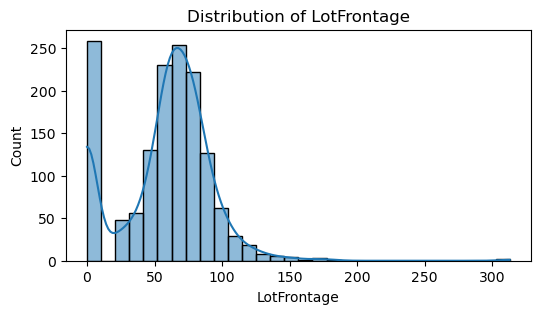

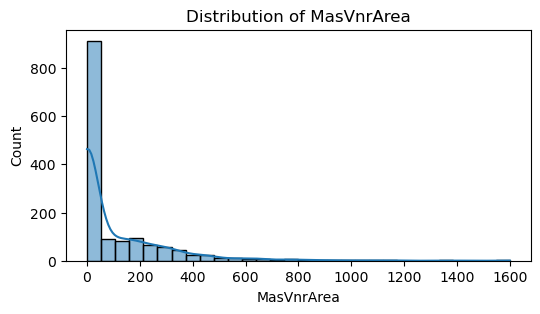

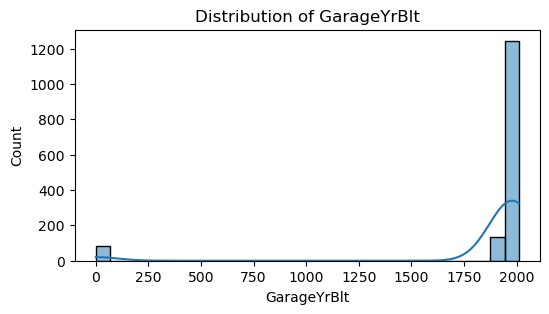

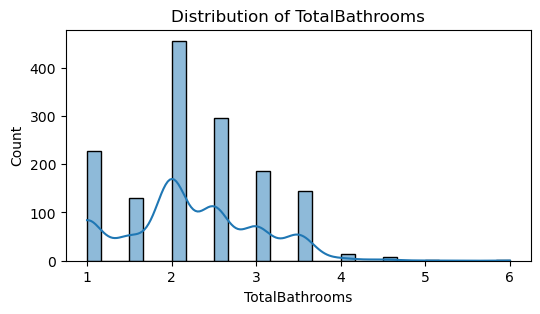

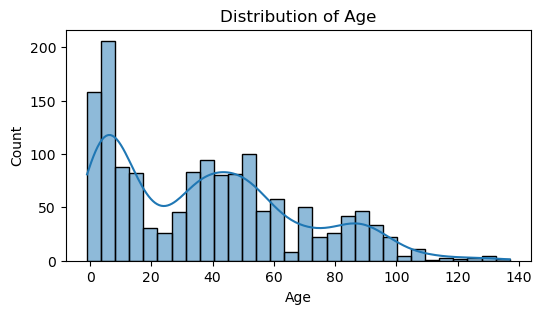

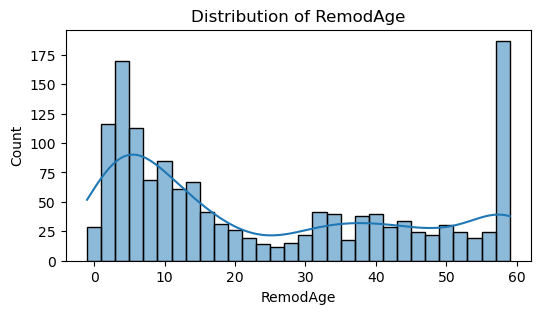

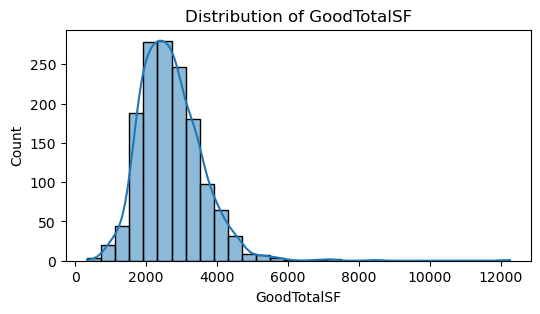

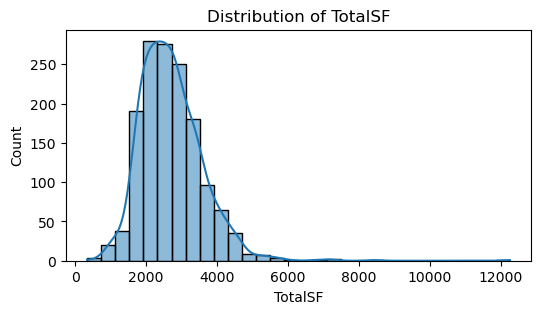

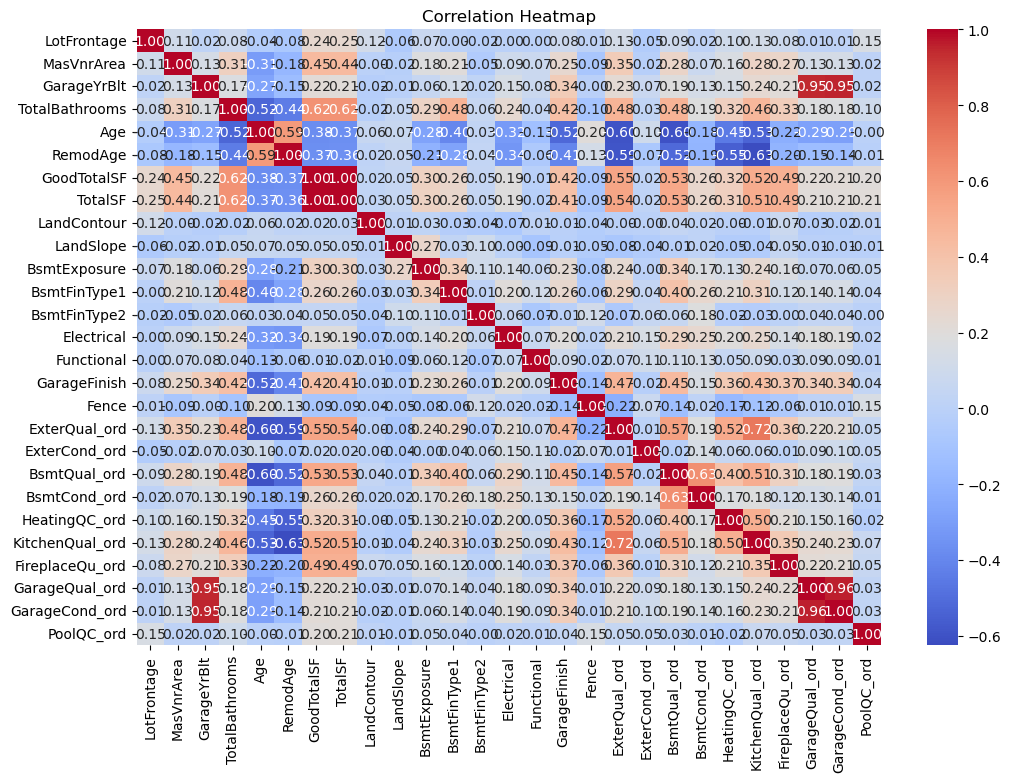

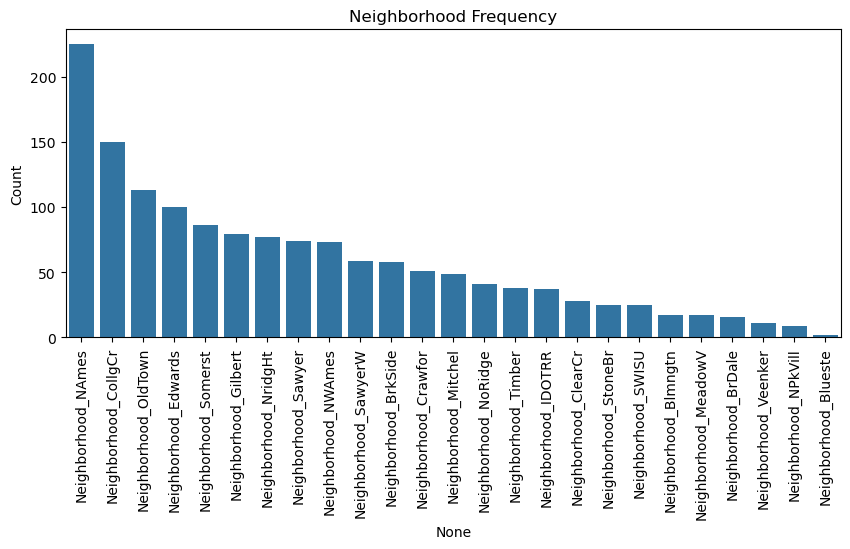

In [108]:
# Visualization: Histograms for continuous/engineered features
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = [
    'LotFrontage', 'MasVnrArea', 'GarageYrBlt', 'TotalBathrooms', 'Age', 'RemodAge', 'GoodTotalSF', 'TotalSF'
]

for col in continuous_features:
    plt.figure(figsize=(6, 3))
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

ordinal_features = [col for col in data.columns if col.endswith('_ord') or col in ['LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Fence', 'Electrical', 'Functional']]

corr_cols = [col for col in continuous_features + ordinal_features if col in data.columns]
plt.figure(figsize=(12, 8))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

onehot_cols = [col for col in data.columns if col.startswith('Neighborhood_')]
if onehot_cols:
    neighborhood_counts = data[onehot_cols].sum().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=neighborhood_counts.index, y=neighborhood_counts.values)
    plt.xticks(rotation=90)
    plt.title('Neighborhood Frequency')
    plt.ylabel('Count')
    plt.show()

In [109]:
# Axis Prep
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from tabulate import tabulate

# Set 'SalePrice' as y
y = data['SalePrice'] if 'SalePrice' in data.columns else None
X = data.drop(columns=['SalePrice']) if 'SalePrice' in data.columns else data.copy()


if y is not None:
    # Impute missing values (if any)
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    # Train/test split
    X_train_hierarchical, X_test_hierarchical, y_train_hierarchical, y_test_hierarchical = train_test_split(X_scaled, y.values, test_size=0.2, random_state=1234)

    X_total = X_train_hierarchical
    y_total = y_train_hierarchical

    X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.2, random_state=1234)



In [110]:
torch.manual_seed(50) # this makes results reproducable

# If using a GPU, use option 1, if not, use option 2.
 # (If we using GPU, we need to place the class we defined to be put onto the GPU)

# 1
# this says " if there is a GPU, make sure my model can be used on the GPU"
# "if a GPU is not available, then use the CPU"

# 2
#model = mynetwork()

#training settings
batch_size = 100
num_epochs = 500
learning_rate = 1e-3
criterion = nn.MSELoss()

# print interval during the training
print_interval=20

# what this does is save the actual gpu device to a variable.
# in the next cell, we will use this `device` variable
# to say "make my data compatable with my model if it is on the GPU"


In [111]:
def train(training_inputs, training_outputs, network, epochs, learning_rate,
          batch_size, loss_function, print_interval):
  """
  Trains a neural network model using the specified parameters.

  Args:
      training_inputs (numpy.ndarray): Input data (features) for training.
      training_outputs (numpy.ndarray): Target outputs (labels) for training.
      network (torch.nn.Module): The neural network model to be trained.
      epochs (int): Number of training epochs.
      learning_rate (float): Learning rate for optimization.
      batch_size (int): Batch size for mini-batch gradient descent.
      loss_function (torch.nn.Module): Loss function for optimization.
      print_interval (int): Interval for printing training progress.

  Returns:
      None
  """
  train_dataset = torch.utils.data.TensorDataset(torch.from_numpy(training_inputs).float(),
                                                 torch.from_numpy(training_outputs).float())

  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                             shuffle=True)

  optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate, weight_decay=1e-5)
  track_losses = np.zeros(epochs)

  start = time.time()

  # here is the main part of the training procedure.
  for epoch in range(1, epochs+1):
      for batch_idx, (X, y) in enumerate(train_loader):
          # grab the x's for this batch
          data = X

          data = data.to(DEVICE)

          # find the predictions f(x) for this batch using the forward() method
          output = network.forward(data)

          # find the loss. This calculates MSE using the pytorch version of MSE
          # ('criterion` in previous cell)
          loss = loss_function(output, y.view([-1, 1]).to(DEVICE))

          optimizer.zero_grad()

          # "calculate the gradients for the model parameters"
          loss.backward()

          # "add the gradients to the model parameters"
          optimizer.step()

      # housekeeping - keep track of our losses and print them as we go
      training_loss = loss.item()**.5
      track_losses[epoch-1] = training_loss
      if epoch % print_interval == 0:
          print('epoch: %4d training loss:%10.3e time:%7.1f'%(epoch, training_loss, time.time()-start))

  return network, track_losses

In [112]:
def model_eva(XTrain,XTest,yTrain,yTest,model):
  """
  Evaluates a machine learning model's performance on training and test data.

  Args:
    XTrain (numpy.ndarray): Training input features.
    XTest (numpy.ndarray): Test input features.
    yTrain (numpy.ndarray): Actual training target values.
    yTest (numpy.ndarray): Actual test target values.
    model (torch.nn.Module): Trained PyTorch model.

  Returns:
    tuple: A tuple containing the following evaluation metrics:
    - MAE_train (float): Mean Absolute Error on the training set.
    - MSE_train (float): Mean Squared Error on the training set.
    - RMSE_train (float): Root Mean Squared Error on the training set.
    - R2_train (float): R-squared (coefficient of determination) on the training set.
    - MAE_test (float): Mean Absolute Error on the test set.
    - MSE_test (float): Mean Squared Error on the test set.
    - RMSE_test (float): Root Mean Squared Error on the test set.
    - R2_test (float): R-squared (coefficient of determination) on the test set.
  """
  # since we have placed our model onto the gpu, we must also ensure that the
  # inputs to the model are also compatable with the gpu, so we manually tell
  # pytorch to make a new Tensor from our numpy array, and add the .cuda() to
  # ensure that this new tensor is GPU-compatable.
  XTrain_th = torch.from_numpy(XTrain).float().to(DEVICE)
  XTest_th = torch.from_numpy(XTest).float().to(DEVICE)
  #yTrain_th=torch.Tensor(yTrain).cuda()
  #yTest_th=torch.Tensor(yTest).cuda()

  # get predictions on the training set
  yTrain_pred = model.forward(XTrain_th)

  # since we are using sklearn functions, these must be numpy arrays,
  # so we manually change them from torch.Tensors to np.ndarray's
  yTrain_pred_np = yTrain_pred.cpu().detach().numpy().reshape(-1)

  yTest_pred = model.forward(XTest_th)
  yTest_pred_np = yTest_pred.cpu().detach().numpy().reshape(-1)

  MAE_train=mean_absolute_error(yTrain_pred_np,yTrain)
  MSE_train=mean_squared_error(yTrain_pred_np,yTrain)
  RMSE_train=np.sqrt(mean_squared_error(yTrain_pred_np,yTrain))
  R2_train=r2_score(yTrain_pred_np,yTrain)

  MAE_test=mean_absolute_error(yTest_pred_np,yTest)
  MSE_test=mean_squared_error(yTest_pred_np,yTest)
  RMSE_test=np.sqrt(mean_squared_error(yTest_pred_np,yTest))
  R2_test=r2_score(yTest_pred_np,yTest)

  return MAE_train,MSE_train,RMSE_train,R2_train,MAE_test,MSE_test,RMSE_test,R2_test

In [113]:
if torch.cuda.is_available():
    print('CUDA available')
    print(torch.cuda.get_device_name(0))
else:
    print('CUDA *not* available')


CUDA *not* available


In [114]:
X_train.shape

(934, 226)

In [115]:
class mynetwork_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.structure = nn.Sequential(
            nn.Linear(226,100),
            nn.ReLU(), # this is a different type of activation function
            nn.Linear(100,80),
            nn.ReLU(),
            nn.Linear(80,50),
            nn.ReLU(), # But what is the key difference?
            nn.Linear(50,1)
        )

    def forward(self, x):
        x = self.structure(x)
        return x

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_1 = mynetwork_1().to(DEVICE)

In [116]:
batch_size = 100
num_epochs = 2000
learning_rate = 1e-2
criterion = nn.MSELoss()

network_1, losses = train(X_train, y_train, model_1, num_epochs, learning_rate, batch_size, criterion, print_interval)


epoch:   20 training loss: 3.291e+04 time:    0.5
epoch:   40 training loss: 2.300e+04 time:    0.9
epoch:   60 training loss: 8.266e+03 time:    1.4
epoch:   80 training loss: 1.107e+04 time:    1.8
epoch:  100 training loss: 1.256e+04 time:    2.3
epoch:  120 training loss: 8.457e+03 time:    2.8
epoch:  140 training loss: 1.114e+04 time:    3.2
epoch:  160 training loss: 4.821e+03 time:    3.7
epoch:  180 training loss: 4.981e+03 time:    4.2
epoch:  200 training loss: 4.760e+03 time:    4.7
epoch:  220 training loss: 8.926e+03 time:    5.2
epoch:  240 training loss: 6.061e+03 time:    5.7
epoch:  260 training loss: 3.606e+03 time:    6.1
epoch:  280 training loss: 3.158e+03 time:    6.6
epoch:  300 training loss: 2.773e+03 time:    7.0
epoch:  320 training loss: 4.137e+03 time:    7.5
epoch:  340 training loss: 2.479e+03 time:    7.9
epoch:  360 training loss: 2.340e+03 time:    8.4
epoch:  380 training loss: 2.190e+03 time:    8.9
epoch:  400 training loss: 1.715e+03 time:    9.3


In [117]:
MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1 = model_eva(X_train,X_test,y_train,y_test,network_1)
results = []

results.append(["NN_1",MAE_train_nn1,MSE_train_nn1,RMSE_train_nn1,R2_train_nn1,MAE_test_nn1,MSE_test_nn1,RMSE_test_nn1,R2_test_nn1])

print(tabulate(results, headers=["Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2", "Test MAE", "Test MSE", "Test RMSE", "Test R^2"],tablefmt="grid"))

+---------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
| Model   |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |    Test MSE |   Test RMSE |   Test R^2 |
+=========+================+================+=================+================+============+=============+=============+============+
| NN_1    |        831.607 |    1.30791e+06 |         1143.64 |       0.999801 |    23879.3 | 1.34739e+09 |     36706.9 |   0.806714 |
+---------+----------------+----------------+-----------------+----------------+------------+-------------+-------------+------------+
